# Preparación y exploración de Amazon Reviews 2023

Trabajaremos con las reseñas y los metadatos de **Subscription Boxes**. Esta notebook
muestra las funciones de descarga y lectura que puedes adaptar en `support.data`,
y permite reconocer los datos antes de construir la búsqueda.

Cópiala a la raíz de tu proyecto `uv` y selecciona su `.venv` como kernel en el IDE.
Necesita `pandas`, `matplotlib` e `ipykernel`. Los archivos se guardan en `data/`.
Consulta el [enunciado](./README.md) y la [guía](./GUIA.md) para el resto de la aplicación.


In [1]:
import gzip
import json
import urllib.request
from collections.abc import Iterator
from pathlib import Path
from typing import Any, TypedDict

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = Path("data")
BASE_URL = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw"
FILES = {
    "reviews.jsonl.gz": f"{BASE_URL}/review_categories/Subscription_Boxes.jsonl.gz",
    "products.jsonl.gz": f"{BASE_URL}/meta_categories/meta_Subscription_Boxes.jsonl.gz",
}


Matplotlib is building the font cache; this may take a moment.


## 1. Descargar los archivos

`download()` recibe la carpeta de destino y reutiliza los archivos existentes.
Se escribe primero un archivo temporal para evitar conservar una descarga incompleta
con el nombre definitivo. No se descarga el modelo de embeddings en esta etapa.


In [2]:
def download(directory: Path) -> None:
    directory.mkdir(parents=True, exist_ok=True)
    for filename, url in FILES.items():
        target = directory / filename
        if target.exists():
            print(f"Using existing file: {target}")
            continue
        temporary = target.with_suffix(".part")
        print(f"Downloading: {filename}")
        with urllib.request.urlopen(url, timeout=120) as source:
            with temporary.open("wb") as output:
                while chunk := source.read(1024 * 1024):
                    output.write(chunk)
        temporary.replace(target)


download(DATA_DIR)


Using existing file: data/reviews.jsonl.gz
Using existing file: data/products.jsonl.gz


## 2. Leer JSONL comprimido

Cada línea contiene un objeto JSON independiente. `gzip.open(..., "rt")` permite
leer texto del archivo comprimido; `json.loads()` convierte cada línea en un
diccionario. `rows()` devuelve el número de línea original junto con el registro.
Ese número permite identificar una reseña incluso si después se filtran registros.


In [3]:
def rows(path: Path) -> Iterator[tuple[int, dict[str, Any]]]:
    with gzip.open(path, "rt", encoding="utf-8") as stream:
        for line_number, text in enumerate(stream, start=1):
            if text.strip():
                yield line_number, json.loads(text)


source_line, first_review = next(rows(DATA_DIR / "reviews.jsonl.gz"))
print("Source line:", source_line)
print("Fields:", list(first_review))
print("Product:", first_review["parent_asin"])
print("Rating:", first_review["rating"])
print("Text:", first_review.get("text", "")[:300])


Source line: 1
Fields: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
Product: B09WC47S3V
Rating: 1.0
Text: Absolutely useless nonsense and a complete waste of money. Kitty didn't like any of the items


## 3. Preparar registros para la aplicación

`load()` selecciona los campos que utilizaremos y crea IDs como
`Subscription_Boxes:123`. `parent_asin` identifica al producto, no a la reseña.

`ReviewRecord` describe un diccionario mediante anotaciones de tipo; no valida
los valores al ejecutarse. Las comprobaciones dentro de `load()` verifican los
campos que necesita la aplicación. Las reseñas sin texto se conservan para estadísticas.
Los títulos de productos se guardan en una relación independiente por ID.


In [4]:
class ReviewRecord(TypedDict):
    review_id: str
    product_id: str
    text: str
    rating: float


def load(directory: Path) -> tuple[list[ReviewRecord], dict[str, str]]:
    products: dict[str, str] = {}
    for line_number, product in rows(directory / "products.jsonl.gz"):
        product_id = product.get("parent_asin")
        title = product.get("title") or ""
        if not isinstance(product_id, str) or not product_id.strip():
            raise ValueError(f"Invalid product ID at line {line_number}")
        if not isinstance(title, str):
            raise ValueError(f"Invalid product title at line {line_number}")
        if product_id in products:
            raise ValueError(f"Duplicate product ID at line {line_number}")
        products[product_id] = title

    records: list[ReviewRecord] = []
    for line_number, review in rows(directory / "reviews.jsonl.gz"):
        product_id = review.get("parent_asin")
        rating = review.get("rating")
        text = review.get("text") or ""
        if not isinstance(product_id, str) or not product_id.strip():
            raise ValueError(f"Invalid product ID at review line {line_number}")
        if isinstance(rating, bool) or not isinstance(rating, (int, float)):
            raise ValueError(f"Invalid rating at review line {line_number}")
        if rating not in (1, 2, 3, 4, 5) or not isinstance(text, str):
            raise ValueError(f"Invalid review at line {line_number}")
        records.append({
            "review_id": f"Subscription_Boxes:{line_number}",
            "product_id": product_id,
            "text": text,
            "rating": float(rating),
        })
    return records, products


records, products = load(DATA_DIR)
reviews_df = pd.DataFrame(records)
products_df = pd.DataFrame(
    list(products.items()), columns=["product_id", "product_title"]
)
print("Reviews:", len(reviews_df))
print("Products in reviews:", reviews_df["product_id"].nunique())
print("Products in catalog:", len(products_df))
reviews_df.head()


Reviews: 16216
Products in reviews: 641
Products in catalog: 641


,review_id,product_id,text,rating
0,Subscription_Boxes:1,B09WC47S3V,Absolutely useless nonsense and a complete was...,1.0
1,Subscription_Boxes:2,B07QL1JRCN,"With a couple of the items, I wasn't quite sur...",2.0
2,Subscription_Boxes:3,B08N5QKX1Y,Two SMALL stuffed animals and 2 little bags of...,1.0
3,Subscription_Boxes:4,B07KM6T8GV,"Although I don’t remember signing up for this,...",5.0
4,Subscription_Boxes:5,B07NVKNVNM,I loved every thing and could use it all. Thin...,5.0


## 4. Relacionar las reseñas con el catálogo

La unión utiliza el ID del producto. `validate="many_to_one"` comprueba que el
catálogo tiene un registro por producto; `how="left"` conserva todas las reseñas,
incluso si falta su producto en el catálogo. No relaciones los archivos por posición.


In [5]:
review_catalog = reviews_df.merge(
    products_df, on="product_id", how="left", validate="many_to_one", indicator=True
)
print("Reviews without catalog metadata:", int((review_catalog["_merge"] == "left_only").sum()))
review_catalog[["review_id", "product_id", "product_title", "rating", "text"]].head()


Reviews without catalog metadata: 0


,review_id,product_id,product_title,rating,text
0,Subscription_Boxes:1,B09WC47S3V,KitNipBox | Happy Cat Box | Monthly Cat Subscr...,1.0,Absolutely useless nonsense and a complete was...
1,Subscription_Boxes:2,B07QL1JRCN,Lip Monthly - Beauty and Makeup Subscription Box,2.0,"With a couple of the items, I wasn't quite sur..."
2,Subscription_Boxes:3,B08N5QKX1Y,"BarkBox Monthly Subscription Box, Dog Chew Toy...",1.0,Two SMALL stuffed animals and 2 little bags of...
3,Subscription_Boxes:4,B07KM6T8GV,How to be a Redhead - Redhead Friendly Approve...,5.0,"Although I don’t remember signing up for this,..."
4,Subscription_Boxes:5,B07NVKNVNM,COCOTIQUE - Beauty & Self-Care Subscription Bo...,5.0,I loved every thing and could use it all. Thin...


## 5. Reconocer el alcance de los datos

Inspecciona valores faltantes, textos vacíos y cantidad de reseñas por producto.
Un texto con espacios también se considera vacío. Una media calculada con pocas
reseñas requiere una interpretación distinta de una respaldada por cientos.


In [6]:
has_text = reviews_df["text"].str.strip().ne("")
print("Reviews with text:", int(has_text.sum()))
print("Reviews without text:", int((~has_text).sum()))
print("Unique review IDs:", reviews_df["review_id"].is_unique)
print("Missing values:")
print(reviews_df.isna().sum())
reviews_per_product = reviews_df.groupby("product_id").size()
reviews_per_product.describe()


Reviews with text: 16205
Reviews without text: 11
Unique review IDs: True
Missing values:
review_id     0
product_id    0
text          0
rating        0
dtype: int64


count     641.000000
mean       25.297972
std       104.019710
min         1.000000
25%         1.000000
50%         4.000000
75%        13.000000
max      1772.000000
dtype: float64

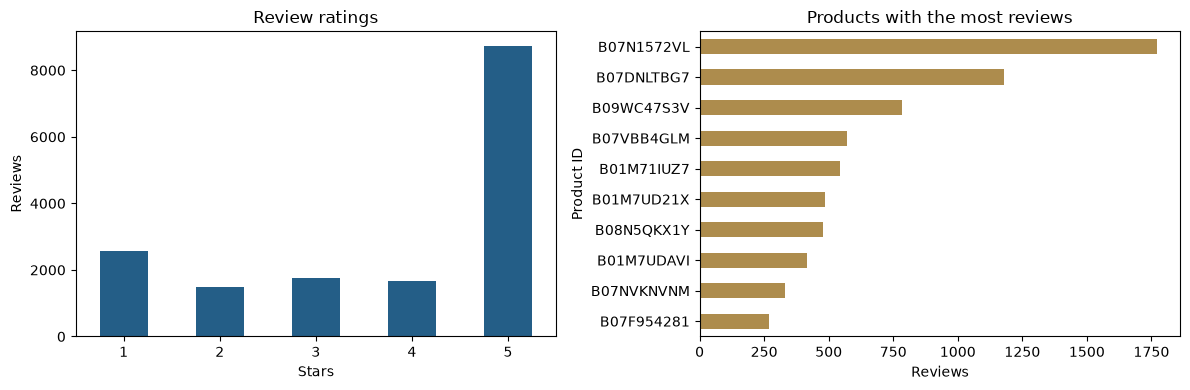

In [7]:
rating_counts = reviews_df["rating"].value_counts().reindex([1, 2, 3, 4, 5], fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rating_counts.plot.bar(ax=axes[0], color="#245E87", rot=0)
axes[0].set(title="Review ratings", xlabel="Stars", ylabel="Reviews")
reviews_per_product.nlargest(10).sort_values().plot.barh(ax=axes[1], color="#AD8C4D")
axes[1].set(title="Products with the most reviews", xlabel="Reviews", ylabel="Product ID")
fig.tight_layout()
plt.show()


La primera gráfica describe las valoraciones observadas en esta categoría. La
segunda muestra que los productos tienen distintos tamaños de muestra; los diez
más reseñados no son necesariamente los mejor valorados. Estas gráficas sirven
para explorar, no son un entregable adicional del proyecto.


In [8]:
example_product = reviews_per_product.idxmax()
example_reviews = review_catalog.loc[review_catalog["product_id"] == example_product]
print("Product ID:", example_product)
print("Title:", products.get(example_product, "Unknown product"))
print("Review count:", len(example_reviews))
print("Observed mean:", example_reviews["rating"].mean())
print("Observed median:", example_reviews["rating"].median())
example_reviews[["review_id", "rating", "text"]].head()


Product ID: B07N1572VL
Title: Allure Beauty Box - The Best in Beauty Delivered Monthly
Review count: 1772
Observed mean: 3.760158013544018
Observed median: 5.0


,review_id,rating,text
14,Subscription_Boxes:15,3.0,"Avid fan of Allure Mag, been reading for at Le..."
26,Subscription_Boxes:27,3.0,Love the box except for the few items that are...
42,Subscription_Boxes:43,5.0,I love this beauty box! The products were awes...
44,Subscription_Boxes:45,5.0,I love getting these boxes. It is so much fun...
54,Subscription_Boxes:55,4.0,[[VIDEOID:4cb51571d146785c0f99045f2d6cddac]] W...


Las estadísticas del servidor deben calcularse con las reseñas cargadas. La media
`average_rating` del catálogo puede describir otro conjunto de valoraciones y no
sustituye este cálculo. Los ejemplos con pandas ayudan a reconocer los datos;
implementa las operaciones numéricas de las herramientas con NumPy o PyTorch.

## 6. Seleccionar textos e IDs para los embeddings

Conserva todas las reseñas para estadísticas y selecciona solo las que tienen texto
para generar vectores. Obtén textos e IDs de la misma selección y en el mismo orden.


In [9]:
searchable_reviews = reviews_df.loc[has_text].copy()
texts: list[str] = searchable_reviews["text"].str.strip().tolist()
review_ids: list[str] = searchable_reviews["review_id"].tolist()
print("Texts to encode:", len(texts))
print("First review ID:", review_ids[0])
print("First text:", texts[0][:200])
assert len(texts) == len(review_ids)
assert len(set(review_ids)) == len(review_ids)


Texts to encode:

 16205
First review ID: Subscription_Boxes:1
First text: Absolutely useless nonsense and a complete waste of money. Kitty didn't like any of the items


Continúa en tu aplicación: implementa la carga de configuración y la codificación de textos,
retomando la [sección de embeddings de PyTorch](../unidad-02-procesamiento-datos/sesion-03-pytorch/u2_n4_tensores_datasets.ipynb).
La fila `i` de la matriz deberá representar el texto e ID de la posición `i`.
Conserva esa correspondencia al consultar. Puedes mantener la matriz en memoria
o guardarla para reutilizarla después.

## Referencias

- [Amazon Reviews 2023 y diccionario de datos](https://amazon-reviews-2023.github.io/).
- [Lectura de gzip](https://docs.python.org/3/library/gzip.html).
- [Lectura de JSON](https://docs.python.org/3/library/json.html).
- [Uniones con pandas](https://pandas.pydata.org/docs/user_guide/merging.html).
- [Modelo all-MiniLM-L6-v2](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2).
